In [ ]:
PyTorch is a Python library for building and training machine learning models, especially neural networks.

A ML model is a program trained on data using algioritms that can learn to recioginze patterns in data.
This allows a trained ML model to make predictions on new unseen data

Examples:

Predicting the weather on a given day using forecast history.
Classifying an image as a cat or dog based on a training data set.
Generating the most likely next word in a sentence given a trained corpus.

We can see that using ml algorithms, we can build programs that rather can produce a desired output based on the data we feed it.

What separates ml from more classical imperative style programming is that instead of hardcoding a program to look for given features in a data set and perform defined operations once those features are identified, ML algorithms are capable of learning how to make predictions given raw data and time fr training.


-- Give example of a simple neural net and how it is trained.

## Example: A Simple Neural Net

Let's build a model that predicts a number based on a single input feature using a linear relationship, like this:

### y = weight * x + bias

In [2]:
import torch   # import the pytorch library
import torch.nn as nn  # import pytorch neural net submodule as nn, making it easier to call

# Step 1: Define a simple linear regression model
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)  # One input → One output

    def forward(self, x):
        return self.linear(x)

model = SimpleNN()


# 🧠 How Does Training Work?
We want the model to learn to predict y values from input x values. Here's how we train it:

### Step-by-step:

In [3]:
# Step 2: Create training data (e.g., y = 2x + 1)
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[3.0], [5.0], [7.0], [9.0]])

# Step 3: Define a loss function and optimizer
loss_fn = nn.MSELoss()  # Mean Squared Error loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # Gradient Descent


In [4]:
# Training loop

In [5]:
# Step 4: Train the model
for epoch in range(100):
    y_pred = model(X)            # Forward pass: predict
    loss = loss_fn(y_pred, y)    # Compute loss (how wrong the prediction is)

    optimizer.zero_grad()        # Clear previous gradients
    loss.backward()              # Backward pass: compute gradients
    optimizer.step()             # Update weights & bias

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 16.3666
Epoch 10, Loss: 0.4236
Epoch 20, Loss: 0.0111
Epoch 30, Loss: 0.0004
Epoch 40, Loss: 0.0001
Epoch 50, Loss: 0.0001
Epoch 60, Loss: 0.0001
Epoch 70, Loss: 0.0001
Epoch 80, Loss: 0.0001
Epoch 90, Loss: 0.0001


# ✅ Final Result
After training, the model learns the relationship between x and y. It can now make predictions on new, unseen data:

In [7]:
new_x = torch.tensor([[5.0]])
print("Prediction for x=5.0:", model(new_x).item())  # Should be close to 11.0


Prediction for x=5.0: 10.983281135559082


# 🔁 Summary of What’s Happening:
### Step	        What’s Happening at this step
1. Define           model	Build a small neural network
2. Provide          data	Give input/output examples
3. Measure          loss	Compare predictions to ground truth
4. Backpropagate	Calculate how to change weights & biases
5. Optimize	        Adjust parameters to improve the model


# Summary What This Code Does
We just trained a tiny neural network to learn the relationship:

### y=2x+1

Using 4 simple data points: [[1.0], [2.0], [3.0], [4.0]]

Trains the model using gradient descent (we'll learn more about this step later).

Tracks the loss (error) at each epoch.

Makes a final prediction for x = 5.0 the brand new data point we provided our trained network.



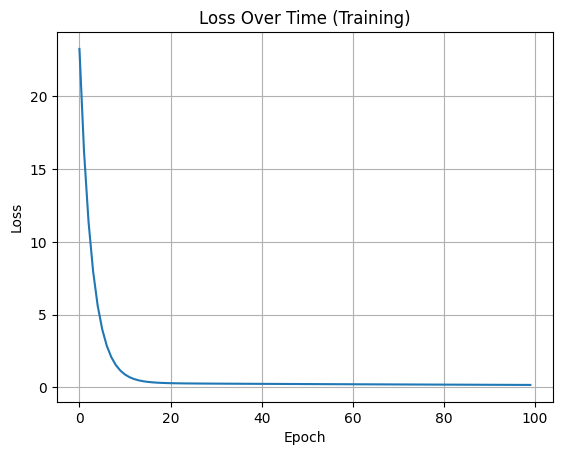

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define model
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

# Training data
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[3.0], [5.0], [7.0], [9.0]])

# Model, loss, optimizer
model = SimpleNN()
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Train
losses = []
for epoch in range(100):
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Visualize
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Time (Training)")
plt.grid(True)
plt.show()
